
## Project Title: Spam Email Classification using Multinomial Naive Bayes

 ## Author
## Student Name: Ayesha
## Roll Number:1670   
 ## supervised by:  Sakin Jan 
__________

## Project Objective:
To classify emails as Spam or Ham using Multinomial Naive Bayes

## Dataset Description:
Dataset contains emails with labels (spam/ham).

## Machine Learning Algorithm(s) Used:
Multinomial Naive Bayes

## Required Libraries:
pandas, numpy, matplotlib, seaborn, sklearn

## Instructions to Run the Project:
1. Open notebook in Jupyter
2. Run all cells step by step
3. Keep dataset in same folder

## Expected Output/Results:
Model predicts whether email is Spam or Ham and shows final classification.


# IMPORT LIBRARIES

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# LOAD DATASET

In [16]:
data = pd.read_csv("spam.csv", encoding='latin-1')

# SHOW FIRST 5 ROWS

In [17]:
print(data.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


# KEEP REQUIRED COLUMNS

In [18]:
data = data[['v1', 'v2']]

# RENAME COLUMNS

In [20]:
data.columns = ['label', 'message']

# CONVERT LABELS INTO NUMBERS

In [22]:
data['label'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

# INPUT AND OUTPUT VARIABLES

In [23]:
X = data['message']
y = data['label']

# CONVERT TEXT INTO NUMBERS

In [24]:
cv = CountVectorizer()

X = cv.fit_transform(X)

# SPLIT DATASET

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TRAIN MODEL

In [26]:
model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


# MAKE PREDICTION

In [27]:
y_pred = model.predict(X_test)

# CALCULATE ACCURACY

In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.97847533632287


# CONFUSION MATRIX

In [29]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[952  13]
 [ 11 139]]


# CONFUSION MATRIX GRAPH

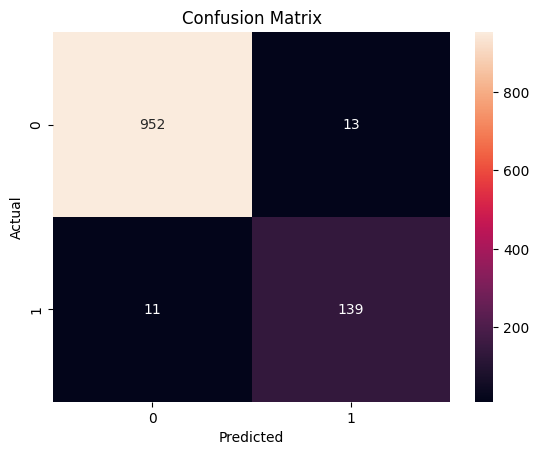

In [30]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# CLASSIFICATION REPORT

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



# TEST CUSTOM EMAIL

In [34]:
email = [
    "Congratulations! You won a free cash prize"
]

# CONVERT EMAIL INTO NUMBERS

In [35]:
email_count = cv.transform(email)

# PREDICT EMAIL

In [36]:
prediction = model.predict(email_count)

# FINAL OUTPUT

In [38]:
if prediction[0] == 1:
    print("Spam Email")

else:
    print("Ham Email")

Spam Email
